In [58]:
# importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt


# loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [59]:
df_us = df[df['job_country'] == "United States"].copy()

In [60]:
df_us['job_posted_month'] = df['job_posted_date'].dt.strftime('%B')

In [61]:
df_us_pivoted = df_us.pivot_table(index = 'job_posted_month', columns = 'job_title_short', aggfunc = 'size')

In [62]:
df_us_pivoted.reset_index('job_posted_month',inplace = True)
df_us_pivoted['Month_no'] = pd.to_datetime(df_us_pivoted['job_posted_month']).dt.month
df_us_pivoted.sort_values(by='Month_no',inplace = True)
df_us_pivoted.set_index('job_posted_month',inplace = True)
df_us_pivoted.drop('Month_no', axis = 1)
df_us_pivoted

C:\Users\arjun\AppData\Local\Temp\ipykernel_3484\2473634000.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_us_pivoted['Month_no'] = pd.to_datetime(df_us_pivoted['job_posted_month']).dt.month


job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Month_no
job_posted_month,,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114,1
February,447,24,6124,3060,4956,56,1258,878,1127,90,2
March,438,19,6218,3183,4779,59,1114,829,1150,115,3
April,565,40,6049,2801,4867,51,1025,781,991,112,4
May,279,20,4993,2976,4377,49,839,746,914,90,5
June,446,32,5683,2893,4645,48,1009,812,1033,93,6
July,581,39,5201,2570,4876,65,883,747,1095,153,7
August,903,39,6634,3269,6318,68,1186,903,1515,194,8
September,897,50,4639,3224,4568,113,805,775,1014,228,9


In [65]:
top3 = df_us['job_title_short'].value_counts().head(3).index.to_list()
top3

['Data Analyst', 'Data Scientist', 'Data Engineer']

Text(0.5, 0, '2023')

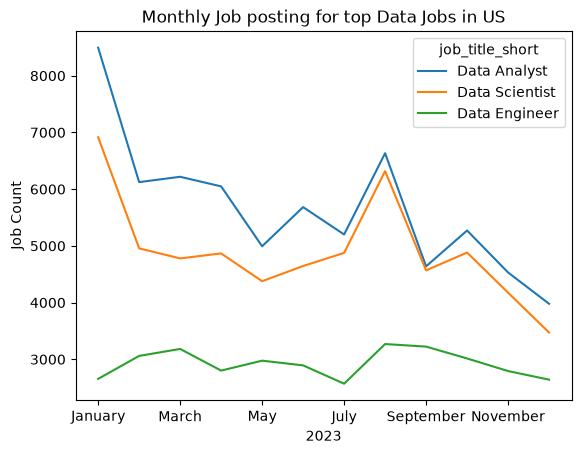

In [69]:
df_us_pivoted[top3].plot(kind='line')
plt.title('Monthly Job posting for top Data Jobs in US')
plt.ylabel('Job Count')
plt.xlabel('2023')